In [41]:
import cobra
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [42]:
# Load the model
model = cobra.io.read_sbml_model("../model.xml")

In [43]:
ecoli_model = cobra.io.read_sbml_model("/Users/helenscott/Documents/PhD/Segre-lab/GEM-repos/ecoli/iJO1366.xml")

In [44]:
# Define a minimal media without C or N
minimal_media = {
    "EX_cpd00058_e0": 1000,  # Cu2+_e0
    "EX_cpd00007_e0": 20,  # O2_e0
    "EX_cpd00971_e0": 1000,  # Na+_e0
    "EX_cpd00063_e0": 1000,  # Ca2+_e0
    "EX_cpd00048_e0": 1000,  # Sulfate_e0
    "EX_cpd10516_e0": 1000,  # fe3_e0
    "EX_cpd00254_e0": 1000,  # Mg_e0
    "EX_cpd00009_e0": 1000,  # Phosphate_e0
    "EX_cpd00205_e0": 1000,  # K+_e0
    "EX_cpd00099_e0": 1000,  # Cl-_e0
    "EX_cpd00030_e0": 1000,  # Mn2+_e0
    "EX_cpd00001_e0": 1000,  # H2O_e0
    "EX_cpd00034_e0": 1000,  # Zn2+_e0
    "EX_cpd00149_e0": 1000,  # Co2+_e0
}

In [45]:
# Define carbon sources to test
c_source = {"Glucose": {"modelseed": "EX_cpd00027_e0", "bigg": "EX_glc__D_e"},
            "Acetate": {"modelseed": "EX_cpd00029_e0", "bigg": "EX_ac_e"},
            "Pyruvate": {"modelseed": "EX_cpd00020_e0", "bigg": "EX_pyr_e"},
            "Succinate": {"modelseed": "EX_cpd00036_e0", "bigg": "EX_succ_e"}}

In [46]:
# Define nitrogen sources to test
n_source = {"Ammonia": {"modelseed": "EX_cpd00013_e0", "bigg": "EX_nh4_e"},
            "Nitrate": {"modelseed": "EX_cpd00209_e0", "bigg": "EX_no3_e"}}

In [47]:
# Add rxn08972 to the model
complexi_rxn = cobra.Reaction("rxn08972_c0")
complexi_rxn.name = "Complex I"
rxn_metabolites = {
    model.metabolites.cpd00004_c0: -1,  # NADH
    model.metabolites.cpd00067_c0: -4,  # H+ (c)
    model.metabolites.cpd15560_c0: -1,  # ubiquinone-8
    model.metabolites.cpd00003_c0: 1,  # NAD
    model.metabolites.cpd00067_e0: 3,  # H+ (e)
    model.metabolites.cpd15561_c0: 1,  # ubiquinol-8
}
complexi_rxn.add_metabolites(rxn_metabolites)
model.add_reactions([complexi_rxn])

In [48]:
model.reactions.rxn08972_c0

Reaction identifier,rxn08972_c0
Name,Complex I
Memory address,0x11f7ea250
Stoichiometry,cpd00004_c0 + 4 cpd00067_c0 + cpd15560_c0 --> cpd00003_c0 + 3 cpd00067_e0 + cpd15561_c0 NADH + 4 H+ + Ubiquinone-8 --> NAD + 3 H+ [e0] + Ubiquinol-8
GPR,
Lower bound,0.0
Upper bound,1000.0


In [49]:
# Save the model as JSON to the desktop so I can make an Escher map
cobra.io.save_json_model(model, "/Users/helenscott/Desktop/model_w_NADH16pp.json")

In [50]:
# Make a list to store results
results_list = []

# For each carbon and nitrogen source, test growth
for c_name, c_dict in c_source.items():
    # Extract the modelseed ID for the carbon source
    c_id = c_dict["modelseed"]
    for n_name, n_dict in n_source.items():
        # Extract the modelseed ID for the nitrogrn source
        n_id = n_dict["modelseed"]

        # Create a copy of the minimal media
        media = minimal_media.copy()

        # Find the metabolite for the carbon source
        carbon_metabolite = model.metabolites.get_by_id(c_id[3:])
        # Get the number of carbons in the carbon source
        n_carbons = carbon_metabolite.elements.get("C", 0)

        # Add the carbon and nitrogen sources to the media
        media[c_id] = 60/n_carbons  # Set the carbon source to 60 mM C
        media[n_id] = 1000
        
        # Set the minimal media
        model.medium = media
        
        # Optimize the model
        solution = model.optimize()
        
        # Store the results
        results_list.append({
            "Carbon Source": c_name,
            "Nitrogen Source": n_name,
            "Media": media,
            "Growth Rate": solution.objective_value
        })

# Create a dataframe from the list of results
results = pd.DataFrame(results_list)

In [51]:
results

,Carbon Source,Nitrogen Source,Media,Growth Rate
0,Glucose,Ammonia,"{'EX_cpd00058_e0': 1000, 'EX_cpd00007_e0': 20,...",1.253265e+00
1,Glucose,Nitrate,"{'EX_cpd00058_e0': 1000, 'EX_cpd00007_e0': 20,...",8.179893e-01
2,Acetate,Ammonia,"{'EX_cpd00058_e0': 1000, 'EX_cpd00007_e0': 20,...",5.088046e-01
3,Acetate,Nitrate,"{'EX_cpd00058_e0': 1000, 'EX_cpd00007_e0': 20,...",3.819935e-14
4,Pyruvate,Ammonia,"{'EX_cpd00058_e0': 1000, 'EX_cpd00007_e0': 20,...",9.738914e-01
5,Pyruvate,Nitrate,"{'EX_cpd00058_e0': 1000, 'EX_cpd00007_e0': 20,...",4.533450e-01
6,Succinate,Ammonia,"{'EX_cpd00058_e0': 1000, 'EX_cpd00007_e0': 20,...",4.529710e-01
7,Succinate,Nitrate,"{'EX_cpd00058_e0': 1000, 'EX_cpd00007_e0': 20,...",8.236099e-15


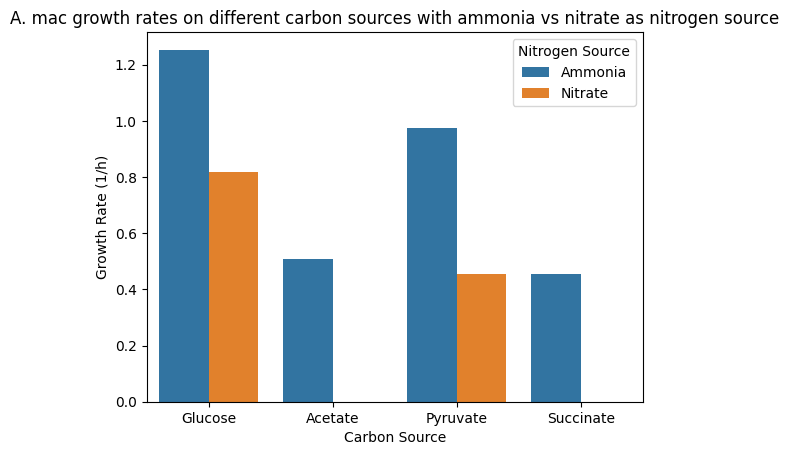

In [52]:
# Plot a paired bar chart of growth rates for each carbon source with ammonia vs nitrate as the nitrogen source
sns.barplot(data=results, x="Carbon Source", y="Growth Rate", hue="Nitrogen Source")
plt.title("A. mac growth rates on different carbon sources with ammonia vs nitrate as nitrogen source")
plt.ylabel("Growth Rate (1/h)")
plt.xlabel("Carbon Source")
plt.legend(title="Nitrogen Source")
plt.show()

## E. coli

In [53]:
ecoli_minimal_media = {
 'EX_co2_e': 1000.0,
 'EX_cobalt2_e': 1000.0,
 'EX_h_e': 1000.0,
 'EX_h2o_e': 1000.0,
 'EX_k_e': 1000.0,
 'EX_cu2_e': 1000.0,
 'EX_mg2_e': 1000.0,
 'EX_mn2_e': 1000.0,
 'EX_mobd_e': 1000.0,
 'EX_na1_e': 1000.0,
 'EX_ca2_e': 1000.0,
 'EX_cbl1_e': 0.01,
 'EX_ni2_e': 1000.0,
 'EX_o2_e': 1000.0,
 'EX_cl_e': 1000.0,
 'EX_pi_e': 1000.0,
 'EX_zn2_e': 1000.0,
 'EX_sel_e': 1000.0,
 'EX_slnt_e': 1000.0,
 'EX_so4_e': 1000.0,
 'EX_tungs_e': 1000.0,
 'EX_fe2_e': 1000.0,
 'EX_fe3_e': 1000.0
 }

In [54]:
# Make a list to store results
ecoli_results_list = []

# For each carbon and nitrogen source, test growth
for c_name, c_dict in c_source.items():
    # Extract the modelseed ID for the carbon source
    c_id = c_dict["bigg"]
    for n_name, n_dict in n_source.items():
        # Extract the modelseed ID for the nitrogen source
        n_id = n_dict["bigg"]

        # Create a copy of the minimal media
        media = ecoli_minimal_media.copy()

        # Find the metabolite for the carbon source
        carbon_metabolite = ecoli_model.metabolites.get_by_id(c_id[3:])
        # Get the number of carbons in the carbon source
        n_carbons = carbon_metabolite.elements.get("C", 0)

        # Add the carbon and nitrogen sources to the media
        media[c_id] = 60/n_carbons  # Set the carbon source to 60 mM C
        media[n_id] = 1000
        
        # Set the minimal media
        ecoli_model.medium = media
        
        # Optimize the model
        solution = ecoli_model.optimize()
        
        # Store the results
        ecoli_results_list.append({
            "Carbon Source": c_name,
            "Nitrogen Source": n_name,
            "Media": media,
            "Growth Rate": solution.objective_value
        })

# Create a dataframe from the list of results
ecoli_results = pd.DataFrame(ecoli_results_list)

In [55]:
ecoli_results

,Carbon Source,Nitrogen Source,Media,Growth Rate
0,Glucose,Ammonia,"{'EX_co2_e': 1000.0, 'EX_cobalt2_e': 1000.0, '...",0.982372
1,Glucose,Nitrate,"{'EX_co2_e': 1000.0, 'EX_cobalt2_e': 1000.0, '...",0.849220
2,Acetate,Ammonia,"{'EX_co2_e': 1000.0, 'EX_cobalt2_e': 1000.0, '...",0.767837
3,Acetate,Nitrate,"{'EX_co2_e': 1000.0, 'EX_cobalt2_e': 1000.0, '...",0.663385
4,Pyruvate,Ammonia,"{'EX_co2_e': 1000.0, 'EX_cobalt2_e': 1000.0, '...",0.732137
5,Pyruvate,Nitrate,"{'EX_co2_e': 1000.0, 'EX_cobalt2_e': 1000.0, '...",0.636396
6,Succinate,Ammonia,"{'EX_co2_e': 1000.0, 'EX_cobalt2_e': 1000.0, '...",0.745510
7,Succinate,Nitrate,"{'EX_co2_e': 1000.0, 'EX_cobalt2_e': 1000.0, '...",0.641128


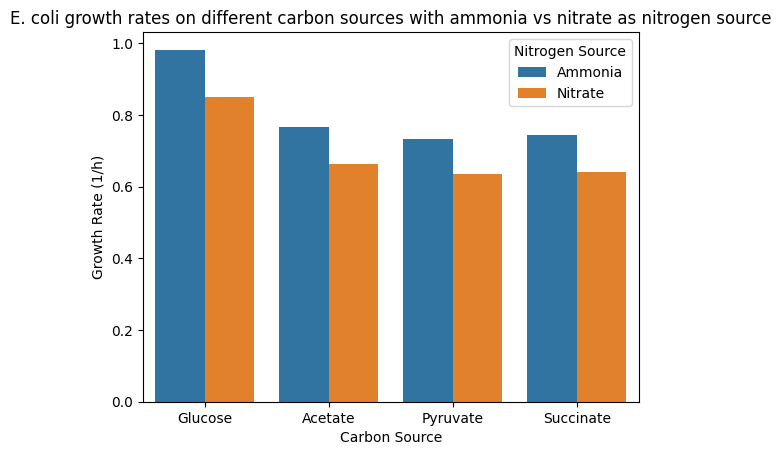

In [56]:
# Plot a paired bar chart of growth rates for each carbon source with ammonia vs nitrate as the nitrogen source
sns.barplot(data=ecoli_results, x="Carbon Source", y="Growth Rate", hue="Nitrogen Source")
plt.title("E. coli growth rates on different carbon sources with ammonia vs nitrate as nitrogen source")
plt.ylabel("Growth Rate (1/h)")
plt.xlabel("Carbon Source")
plt.legend(title="Nitrogen Source")
plt.show()

# Mass Balance Test

In [57]:
mb_results = cobra.manipulation.check_mass_balance(model)
mb_results

{<Reaction rxn05296_c0 at 0x11b0a5f90>: {'charge': -1.1990333335943006,
  'H': -55.87497693167157,
  'O': -8.051088903379139,
  'C': -33.95928986458722,
  'N': -8.838628717915412,
  'S': -0.36173518565949303,
  'R': 2.0},
 <Reaction rxn05294_c0 at 0x11acd2c50>: {'charge': -2.0000000000000115,
  'C': -5.148868603416695,
  'H': -2.315245168395329,
  'N': -7.749564847467959,
  'O': 0.6006962440512922,
  'P': -0.06655062599144834,
  'R': 3.0},
 <Reaction rxn05295_c0 at 0x11986fa90>: {'charge': -3.552713678800501e-15,
  'C': -19.18613309220065,
  'H': -23.59029552989279,
  'N': -7.911477251708783,
  'O': -13.921157087141406,
  'P': -2.0018920171327865},
 <Reaction octanoyl_xfer at 0x11e243f10>: {'H': 2.0, 'N': 1.0, 'R': 1.0}}

In [58]:
# Basically reimplement the mass balance check for a specific reaction to understand how it works
from collections import Counter

reactant_elements = Counter()
product_elements = Counter()

for m, s in model.reactions.rxn14412_c0.metabolites.items():
    # Make a copy to avoid modifying the original metabolite's element dictionary
    elements = m.elements.copy()
    
    if s < 0:  # It's a reactant
        # Multiply by the absolute value of the stoichiometric coefficient
        for key in elements:
            elements[key] *= abs(s)
        reactant_elements += Counter(elements)
    else:  # It's a product
        for key in elements:
            elements[key] *= s
        product_elements += Counter(elements)

print("Reactant Elements:", reactant_elements)
print("Product Elements:", product_elements)

# Check if they are balanced
if reactant_elements == product_elements:
    print("The reaction is mass-balanced.")
else:
    print("The reaction is not mass-balanced.")
    print("Difference (Reactants - Products):", reactant_elements - product_elements)
    print("Difference (Products - Reactants):", product_elements - reactant_elements)

Reactant Elements: Counter({'H': 180.0, 'C': 133.0, 'N': 16.0, 'O': 16.0, 'S': 4.0, 'Fe': 2.0})
Product Elements: Counter({'H': 180.0, 'C': 133.0, 'N': 16.0, 'O': 16.0, 'S': 4.0, 'Fe': 2.0})
The reaction is mass-balanced.


In [59]:
# Print each of the reactions flagged as unbalanced and make a pretty table to put in slides for Daniel
print("ID | Name | Reaction")
print("---|---|---")
for r in mb_results:
    print(f"{r.id} | {r.name} | {r.build_reaction_string(use_metabolite_names=True)}")

ID | Name | Reaction
---|---|---
rxn05296_c0 | Protein synthesis | 27.684983832597 H2O + 35.5949792133389 ATP + 0.388588889398408 L-Glutamate + 0.904337964148734 Glycine + 0.759012038032257 L-Alanine + 0.506271296960121 L-Lysine + 0.356206481948541 L-Aspartate + 0.437557407981134 L-Arginine + 0.388588889398408 L-Glutamine + 0.31829537078772 L-Serine + 0.226676852149071 L-Methionine + 0.0837203704801448 L-Tryptophan + 0.274065741100097 L-Phenylalanine + 0.214039815095465 L-Tyrosine + 0.135058333510422 L-Cysteine + 0.665813889761907 L-Leucine + 0.140587037221375 L-Histidine + 0.326983333762075 L-Proline + 0.356206481948541 L-Asparagine + 0.624743519337685 L-Valine + 0.3743722227131 L-Threonine + 0.42886944500678 L-Isoleucine --> 35.5949792133389 ADP + 35.5949792133389 Phosphate + 35.5949792133389 H+ + Protein
rxn05294_c0 | DNA synthesis | 0.516637656497864 dATP + 0.516637656497864 dGTP + 0.516637656497864 dCTP + 0.516637656497864 TTP --> 2.06655062599146 PPi + DNA
rxn05295_c0 | mRNA synt

# Random Exploration

In [60]:
# Look for reactions that involve both NADH and ubiquinone-8
nadh_reactions = model.metabolites.cpd00004_c0.reactions
ubiquinone_reactions = model.metabolites.cpd15560_c0.reactions
nadh_ubiquinone_reactions = set(nadh_reactions).intersection(set(ubiquinone_reactions))
nadh_ubiquinone_reactions

{<Reaction rxn08972_c0 at 0x11f7ea250>, <Reaction rxn08975_c0 at 0x11ae87690>}